# Consequent Reversibility x Goal Type x Agent Exploration

1. Overall Subgroup
2. Actors
3. Readers

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read data and sanity checks

In [2]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

In [3]:
subgroup_theoretical[
    [
        "Goal_Type",
        "Item",
        "Consequent_Reversibility"
    ]
].drop_duplicates()

,Goal_Type,Item,Consequent_Reversibility
0,no_goal,Item1,Yes
1,no_goal,Item2,Yes
2,goal_non_frequent,Item1,No
3,goal_non_frequent,Item2,No
4,goal_frequent,Item1,Yes
5,goal_frequent,Item2,Yes


In [4]:
subgroup_theoretical.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'Response_Full', 'EXP', 'n',
       'Age', 'Gender', 'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents',
       'Multi_Kno', 'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use',
       'Motivation', 'Distractor', 'GN_Score', 'Difficulty', 'Kno_Level_Label',
       'Per_Level_Label', 'Prof_Need_Label', 'Prof_Use_Label',
       'Consequent_Reversibility'],
      dtype='str')

In [5]:
subgroup_theoretical.shape

(198, 32)

### 1. Overall Subgroup

Response Proportion by Goal Type, Agent and Consequent Reversiblity

In [6]:
goal_agent_reversibility_props= pd.crosstab(
    [subgroup_theoretical["Goal_Type"],subgroup_theoretical["Agent"], subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

goal_agent_reversibility_props

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.309524  0.333333   
                  1     Yes                          0.500000  0.083333   
goal_non_frequent 0     No                           0.500000  0.214286   
                  1     No                           0.666667  0.041667   
no_goal           0     Yes                          0.547619  0.190476   
                  1     Yes                          0.458333  0.166667   

Response_Full                                      correct  missing_response  
Goal_Type         Agent Consequent_Reversibility                              
goal_frequent     0     Yes                       0.333333          0.023810  
                  1     Yes                       0.416667          0.000000  
goal_non_frequent 0     No                        0.285714          0.000000  
                  1     No                        0.291667          0.000000  
no_goal           0     Yes                       0.214286          0.047619  
                  1     Yes                       0.375000          0.000000

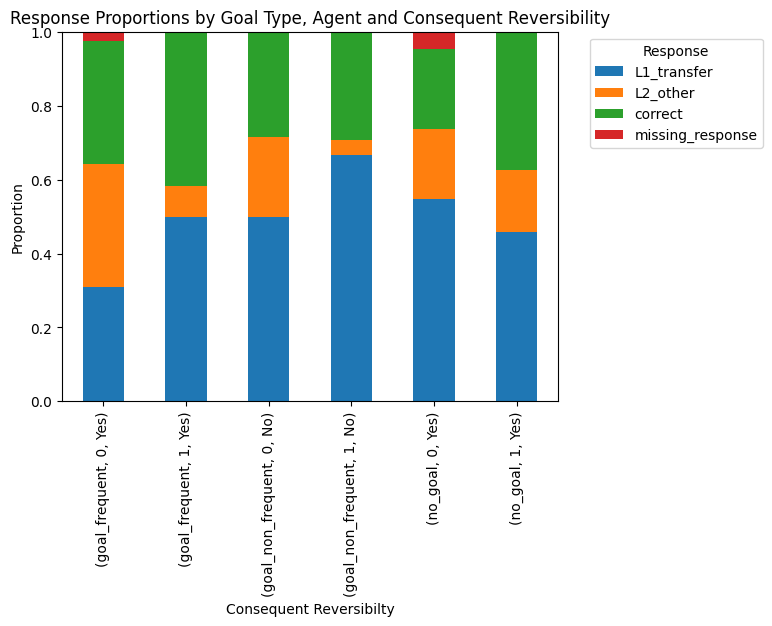

In [7]:
goal_agent_reversibility_props.plot(kind = "bar", stacked=True)

plt.title("Response Proportions by Goal Type, Agent and Consequent Reversibility")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlabel("Consequent Reversibilty")
plt.ylabel("Proportion")
plt.show()

Response Counts by Goal Type, Agent and Consequent Reversiblity

In [8]:
goal_agent_reversibility_counts= pd.crosstab(
    [subgroup_theoretical["Goal_Type"],subgroup_theoretical["Agent"], subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"]
)

goal_agent_reversibility_counts

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                                13        14   
                  1     Yes                                12         2   
goal_non_frequent 0     No                                 21         9   
                  1     No                                 16         1   
no_goal           0     Yes                                23         8   
                  1     Yes                                11         4   

Response_Full                                     correct  missing_response  
Goal_Type         Agent Consequent_Reversibility                             
goal_frequent     0     Yes                            14                 1  
                  1     Yes                            10                 0  
goal_non_frequent 0     No                             12                 0  
                  1     No                              7                 0  
no_goal           0     Yes                             9                 2  
                  1     Yes                             9                 0

- Reversibility matters, but goal oriented structure may be what keeps the counterfactual worth pursuing.
- For readers especially, when there is no self-engagement, having a purpose or a benefit in the undoing could be what does the job.

### 2. Actors

Actors subgroup proportions

In [9]:
subgroup_theoretical_actors = subgroup_theoretical[subgroup_theoretical["Focus"] == "I"].copy()

In [10]:
subgroup_theoretical_actors.shape

(120, 32)

Response Proportion by goal Type, Agent and Consequent Reversiblity for Actors

In [11]:
goal_agent_reversibility_props_a= pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical_actors["Agent"],subgroup_theoretical_actors["Consequent_Reversibility"]],
    subgroup_theoretical_actors["Response_Full"],
    normalize="index"
)

goal_agent_reversibility_props_a

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.250000  0.333333   
                  1     Yes                          0.437500  0.125000   
goal_non_frequent 0     No                           0.291667  0.333333   
                  1     No                           0.687500  0.062500   
no_goal           0     Yes                          0.541667  0.125000   
                  1     Yes                          0.562500  0.125000   

Response_Full                                     correct  missing_response  
Goal_Type         Agent Consequent_Reversibility                             
goal_frequent     0     Yes                        0.3750          0.041667  
                  1     Yes                        0.4375          0.000000  
goal_non_frequent 0     No                         0.3750          0.000000  
                  1     No                         0.2500          0.000000  
no_goal           0     Yes                        0.2500          0.083333  
                  1     Yes                        0.3125          0.000000

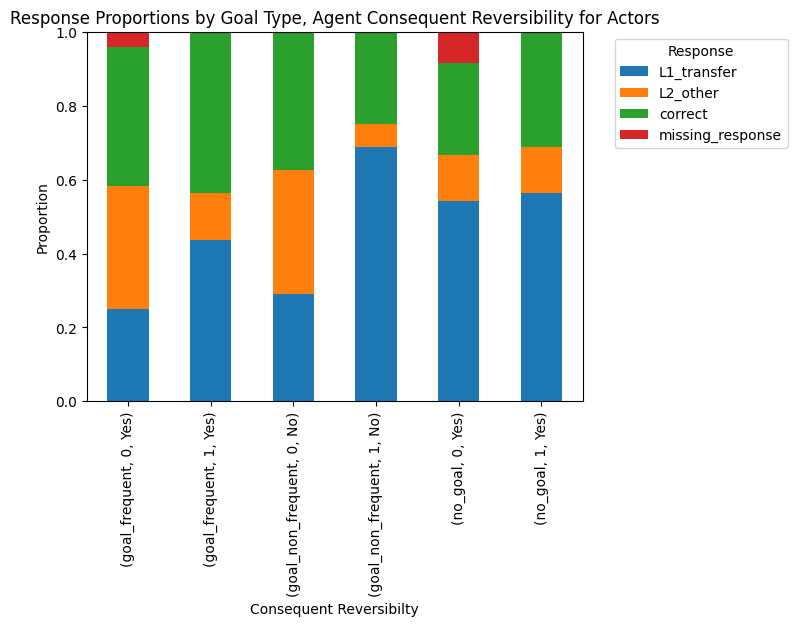

In [12]:
goal_agent_reversibility_props_a.plot(kind = "bar", stacked=True)

plt.title("Response Proportions by Goal Type, Agent Consequent Reversibility for Actors")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlabel("Consequent Reversibilty")
plt.ylabel("Proportion")
plt.show()

- With implicit agency for actors without goals, L1 transfer increases to 59%; once there is an explicit agent, goal frequent (and reversible)'s proportion of correct responses reaches 44%, clearly the best one. 

- The separation between goal_frequent and no_goal appears much larger once Agent is introduced, suggesting that the beneficial effect is not reversibility itself but reversibility in the service of an active goal.

Response Counts by goal Type, Agent and Consequent Reversiblity for Actors

In [13]:
goal_agent_reversibility_counts_a= pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical_actors["Agent"],subgroup_theoretical_actors["Consequent_Reversibility"]],
    subgroup_theoretical_actors["Response_Full"]
)

goal_agent_reversibility_counts_a

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                                 6         8   
                  1     Yes                                 7         2   
goal_non_frequent 0     No                                  7         8   
                  1     No                                 11         1   
no_goal           0     Yes                                13         3   
                  1     Yes                                 9         2   

Response_Full                                     correct  missing_response  
Goal_Type         Agent Consequent_Reversibility                             
goal_frequent     0     Yes                             9                 1  
                  1     Yes                             7                 0  
goal_non_frequent 0     No                              9                 0  
                  1     No                              4                 0  
no_goal           0     Yes                             6                 2  
                  1     Yes                             5                 0

### 3. Readers

Readers subgroup proportions

In [14]:
subgroup_theoretical_readers = subgroup_theoretical[subgroup_theoretical["Focus"] == "They"].copy()

In [15]:
subgroup_theoretical_readers.shape

(78, 32)

Response Proportion by Goal Type, Agent and Consequent Reversiblity for Readers

In [16]:
goal_agent_reversibility_props_r= pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical_readers["Agent"],subgroup_theoretical_readers["Consequent_Reversibility"]],
    subgroup_theoretical_readers["Response_Full"],
    normalize="index"
)

goal_agent_reversibility_props_r

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                          0.388889  0.333333   
                  1     Yes                          0.625000  0.000000   
goal_non_frequent 0     No                           0.777778  0.055556   
                  1     No                           0.625000  0.000000   
no_goal           0     Yes                          0.555556  0.277778   
                  1     Yes                          0.250000  0.250000   

Response_Full                                      correct  
Goal_Type         Agent Consequent_Reversibility            
goal_frequent     0     Yes                       0.277778  
                  1     Yes                       0.375000  
goal_non_frequent 0     No                        0.166667  
                  1     No                        0.375000  
no_goal           0     Yes                       0.166667  
                  1     Yes                       0.500000

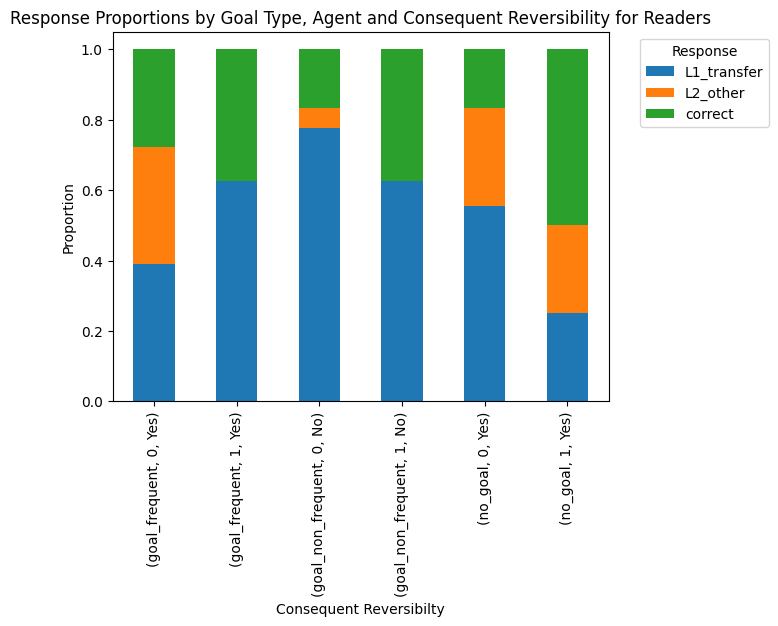

In [17]:
goal_agent_reversibility_props_r.plot(kind = "bar", stacked=True)

plt.title("Response Proportions by Goal Type, Agent and Consequent Reversibility for Readers")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlabel("Consequent Reversibilty")
plt.ylabel("Proportion")
plt.show()

Response Counts by Goal Type, Agent and Consequent Reversiblity for Readers

In [18]:
goal_agent_reversibility_counts_r= pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical_readers["Agent"],subgroup_theoretical_readers["Consequent_Reversibility"]],
    subgroup_theoretical_readers["Response_Full"]
)

goal_agent_reversibility_counts_r

Response_Full                                     L1_transfer  L2_other  \
Goal_Type         Agent Consequent_Reversibility                          
goal_frequent     0     Yes                                 7         6   
                  1     Yes                                 5         0   
goal_non_frequent 0     No                                 14         1   
                  1     No                                  5         0   
no_goal           0     Yes                                10         5   
                  1     Yes                                 2         2   

Response_Full                                     correct  
Goal_Type         Agent Consequent_Reversibility           
goal_frequent     0     Yes                             5  
                  1     Yes                             3  
goal_non_frequent 0     No                              3  
                  1     No                              3  
no_goal           0     Yes                             3  
                  1     Yes                             4

- by this stage, there are very few observations. We can only observ if the same direactional pattern appears across several analyses.

- Goal could determine the direction of processing rather than consequence reversibility. Attachment generally improves performances, but the magnitude varies with goal structure. 

- For both actors and readers, explicit agency doesn't simply improve performance; it seems to magnify whatever the goal structure is already doing, for actors in particular.

- Looking at correct counts, introducing an explicit agent always leads to an increase for readers; agency doesn't seem to harm readers the way it could harm actors once there is a goal structure.

In summary:

- Actors show a cleaner theoretical pattern
- Readers show a weaker pattern mixed with sampling noise; but readers are also meant to be so psychologically as observers. They could show an underlying tendency filtered through much smaller cells and weaker engagement.